# 10 · SMS Mendeley — smishing subtype & Core fit

**Source:** [SMS Phishing Dataset for Machine Learning and Pattern Recognition](https://data.mendeley.com/) — `SMS Mendeley.csv` in `v2/data/raw/`.

**Goal:** map the **Smishing** subset to fraud-SMS subtypes and judge overlap with the Core family `fraud_sms_phishing_like`.

**Primary slice:** rows whose label normalizes to `smishing` (dataset mixes `Smishing`, `smishing`, and a separate `Spam` class — see EDA cell).

**Outputs:**
- `v2/data/interim/annotated/mendeley_smishing_annotated.jsonl` — flat rows (deduped by message text)
- Optional summary tables under `v2/outputs/tables/` after you run the stats cell

**Annotation:** OpenRouter + JSON mode; prompts match the project contract in the code cells below.

**Post-batch checks:** `smish_subtype` distribution, share `core_candidate=yes`, and frequencies of URL / payment / credential / brand flags.

In [10]:
# ── 0. Setup ───────────────────────────────────────────────────────────────
import importlib.util
import json
import os
import time
from datetime import datetime, timezone
from pathlib import Path

import pandas as pd
from dotenv import load_dotenv
from openai import OpenAI, APIError, RateLimitError
from tenacity import retry, stop_after_attempt, wait_exponential, retry_if_exception_type
from tqdm.auto import tqdm


def _find_v2_root() -> Path:
    c = Path(globals().get("__vsc_ipynb_file__", globals().get("__file__", "."))).resolve()
    for p in [c, *c.parents]:
        if (p / "pyproject.toml").exists() and (p / "notebooks").exists():
            return p
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "pyproject.toml").exists() and (p / "notebooks").exists():
            return p
    raise RuntimeError("Cannot find v2/ project root")


V2_ROOT = _find_v2_root()
RAW_CSV = V2_ROOT / "data" / "raw" / "SMS Mendeley.csv"
INTERIM = V2_ROOT / "data" / "interim" / "annotated"
OUT_TABLES = V2_ROOT / "outputs" / "tables"
INTERIM.mkdir(parents=True, exist_ok=True)
OUT_TABLES.mkdir(parents=True, exist_ok=True)

spec = importlib.util.spec_from_file_location(
    "_ann_common", V2_ROOT / "notebooks" / "02_dataset_design" / "_ann_common.py"
)
ac = importlib.util.module_from_spec(spec)
spec.loader.exec_module(ac)

load_dotenv(V2_ROOT / ".env" if (V2_ROOT / ".env").exists() else None)
api_key = os.environ.get("OPENROUTER_API_KEY", "")
if not api_key:
    raise EnvironmentError(f"Set OPENROUTER_API_KEY in {V2_ROOT / '.env'}")

ANNOTATION_MODEL = "openai/gpt-4o-mini"
client = OpenAI(base_url="https://openrouter.ai/api/v1", api_key=api_key)

BATCH_SIZE = 8
SLEEP_SEC = 2.0
MAX_NEW_THIS_RUN = 500  # increase for full pass
OUT_JSONL = INTERIM / "mendeley_smishing_annotated.jsonl"

print("V2_ROOT :", V2_ROOT)
print("CSV     :", RAW_CSV)
print("OUT     :", OUT_JSONL)
print("Model   :", ANNOTATION_MODEL)

V2_ROOT : /Users/askar/projects/antifraud-deepfake-detection/v2
CSV     : /Users/askar/projects/antifraud-deepfake-detection/v2/data/raw/SMS Mendeley.csv
OUT     : /Users/askar/projects/antifraud-deepfake-detection/v2/data/interim/annotated/mendeley_smishing_annotated.jsonl
Model   : openai/gpt-4o-mini


In [11]:
# ── 1. Load CSV & EDA ───────────────────────────────────────────────────────
assert RAW_CSV.exists(), f"Missing: {RAW_CSV}"

df = pd.read_csv(RAW_CSV)
# Normalize labels for filtering (raw file mixes Smishing / smishing / Spam / spam / ham)
df["_label_norm"] = df["LABEL"].astype(str).str.strip().str.lower()

print("Rows:", len(df))
print("\nLABEL value_counts:")
print(df["LABEL"].value_counts())
print("\nNormalized smishing rows:", (df["_label_norm"] == "smishing").sum())
print(
    "Note: raw LABEL 'Spam' (capital S) normalizes to 'spam', not 'smishing':",
    (df["LABEL"].astype(str) == "Spam").sum(),
    "rows — review manually if they should be in the fraud-SMS slice.",
)

# Optional: ham / spam overview (dataset cleanliness)
for lab in ("ham", "spam"):
    sub = df[df["_label_norm"] == lab]
    print(f"\n{lab}: n={len(sub)}  sample TEXT len (chars) median={sub['TEXT'].astype(str).str.len().median():.0f}")

smish = df[df["_label_norm"] == "smishing"].copy()
# Dedupe by TEXT — one annotation per unique SMS body
grp = smish.groupby(smish["TEXT"].astype(str), sort=False)
records: list[dict] = []
for text, g in grp:
    row0 = g.iloc[0]
    records.append(
        {
            "text": text,
            "label_original": str(row0["LABEL"]),
            "url_flag": str(row0.get("URL", "")),
            "email_flag": str(row0.get("EMAIL", "")),
            "phone_flag": str(row0.get("PHONE", "")),
            "n_duplicate_rows": int(len(g)),
        }
    )
print("\nUnique smishing texts to annotate:", len(records))
print("Example:", json.dumps(records[0], ensure_ascii=False, indent=2)[:500], "...")

Rows: 5971

LABEL value_counts:
LABEL
ham         4844
Smishing     616
spam         466
Spam          23
smishing      22
Name: count, dtype: int64

Normalized smishing rows: 638
Note: raw LABEL 'Spam' (capital S) normalizes to 'spam', not 'smishing': 23 rows — review manually if they should be in the fraud-SMS slice.

ham: n=4844  sample TEXT len (chars) median=53

spam: n=489  sample TEXT len (chars) median=143

Unique smishing texts to annotate: 628
Example: {
  "text": "Please Stay At Home. To encourage the notion of staying at home. All tax-paying citizens are entitled to �305.96 or more emergency refund. smsg.io/fCVbD",
  "label_original": "Smishing",
  "url_flag": "No",
  "email_flag": "No",
  "phone_flag": "No",
  "n_duplicate_rows": 1
} ...


## Annotation schema (Smishing)

| Field | Values |
|-------|--------|
| `smish_subtype` | account_alert, delivery_fee_or_service_issue, prize_or_contest_scam, financial_or_crypto_lure, loan_or_credit_lure, lawsuit_or_settlement_lure, generic_deceptive_sms, unclear_other |
| `core_candidate` | yes / maybe / no |
| Binary flags | `has_*` as yes/no |
| `confidence` | high / medium / low |

`scenario_family` in the JSONL line is set to `smish_subtype` for compatibility with `_ann_common.load_flat_annotation_index`.

In [12]:
SYSTEM_PROMPT = '''
You are annotating SMS fraud messages for a research dataset on LLM-generated text detection in anti-fraud systems.

Your task is NOT to summarize the message.
Your task is to assign structured labels describing the fraud-SMS subtype.

Return output as strict JSON with the following keys:

{
  "smish_subtype": "...",
  "core_candidate": "...",
  "has_link_or_url": "yes|no",
  "has_phone_or_reply_cta": "yes|no",
  "has_payment_request": "yes|no",
  "has_credential_or_verification_request": "yes|no",
  "has_urgency": "yes|no",
  "has_brand_impersonation": "yes|no",
  "confidence": "high|medium|low"
}

Allowed values for "smish_subtype":
- account_alert
- delivery_fee_or_service_issue
- prize_or_contest_scam
- financial_or_crypto_lure
- loan_or_credit_lure
- lawsuit_or_settlement_lure
- generic_deceptive_sms
- unclear_other

Definitions:
- account_alert: claims suspicious login, blocked account, profile locked, account security problem, card/account issue, verification required
- delivery_fee_or_service_issue: claims parcel problem, customs fee, failed delivery, package hold, service issue requiring action
- prize_or_contest_scam: claims winnings, contest reward, lucky draw, bonus prize, reward redemption
- financial_or_crypto_lure: invites user into crypto/investment/profit scheme, financial opportunity, trading or money-making lure
- loan_or_credit_lure: promotes deceptive credit, loan, debt, or borrowing-related bait
- lawsuit_or_settlement_lure: claims settlement money, legal compensation, lawsuit payment, class action payout
- generic_deceptive_sms: clearly deceptive or phishing-like SMS but no more specific label fits
- unclear_other: text is too noisy, ambiguous, broken, or not clearly one of the above

Allowed values for "core_candidate":
- yes
- maybe
- no

Meaning:
- yes: fits the intended Core SMS fraud family for the dataset
- maybe: somewhat relevant but not canonical or not clearly phishing-like
- no: not suitable for Core

Annotation rules:
1. Choose the most specific subtype that fits.
2. Mark core_candidate=yes only if the message clearly belongs to anti-fraud deceptive SMS communication.
3. Mark core_candidate=maybe if it is scam-like but farther from the intended phishing-like Core.
4. Mark core_candidate=no if it is too broad, too noisy, too conversational, or weakly related.
5. Mark has_brand_impersonation=yes if the message clearly impersonates or invokes a specific institution, company, delivery service, bank, or brand.
6. Mark has_phone_or_reply_cta=yes if the message asks to reply, call, send a number, or otherwise respond directly.
7. Use confidence=low only when the text is strongly ambiguous or corrupted.
8. Output JSON only. No explanation.
'''

USER_TEMPLATE = '''Annotate the following SMS message for fraud subtype analysis.

Message text:
"""{sms_text}"""
'''

In [13]:
# ── 3. Validation & API ────────────────────────────────────────────────────
YN = {"yes", "no"}
SUBTYPES = {
    "account_alert",
    "delivery_fee_or_service_issue",
    "prize_or_contest_scam",
    "financial_or_crypto_lure",
    "loan_or_credit_lure",
    "lawsuit_or_settlement_lure",
    "generic_deceptive_sms",
    "unclear_other",
}
CORE = {"yes", "maybe", "no"}
CONF = {"high", "medium", "low"}


def validate_sms_ann(d: dict) -> dict:
    st = d.get("smish_subtype", "unclear_other")
    if st not in SUBTYPES:
        st = "unclear_other"
    cc = d.get("core_candidate", "maybe")
    if cc not in CORE:
        cc = "maybe"

    def yn(x, default="no"):
        v = str(x).strip().lower()
        return v if v in YN else default

    conf = str(d.get("confidence", "low")).strip().lower()
    if conf not in CONF:
        conf = "low"
    return {
        "smish_subtype": st,
        "core_candidate": cc,
        "has_link_or_url": yn(d.get("has_link_or_url")),
        "has_phone_or_reply_cta": yn(d.get("has_phone_or_reply_cta")),
        "has_payment_request": yn(d.get("has_payment_request")),
        "has_credential_or_verification_request": yn(d.get("has_credential_or_verification_request")),
        "has_urgency": yn(d.get("has_urgency")),
        "has_brand_impersonation": yn(d.get("has_brand_impersonation")),
        "confidence": conf,
    }


def build_messages(sms_text: str) -> list[dict]:
    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": USER_TEMPLATE.format(sms_text=sms_text)},
    ]


@retry(
    retry=retry_if_exception_type((RateLimitError, APIError)),
    wait=wait_exponential(multiplier=2, min=2, max=45),
    stop=stop_after_attempt(6),
)
def call_json(msgs: list[dict]) -> dict:
    raw = client.chat.completions.create(
        model=ANNOTATION_MODEL,
        messages=msgs,
        response_format={"type": "json_object"},
        temperature=0,
        max_tokens=256,
    ).choices[0].message.content
    return json.loads(raw)

In [14]:
# ── 4. Annotate (cached by text md5) ─────────────────────────────────────────
idx = ac.load_flat_annotation_index(OUT_JSONL)
pending = [r for r in records if ac.md5_text_key(r["text"]) not in idx]
print("Already annotated:", len(idx), "| Pending:", len(pending))

batch_i = 0
for r in tqdm(pending[:MAX_NEW_THIS_RUN], desc="mendeley_smishing"):
    try:
        ann = validate_sms_ann(call_json(build_messages(r["text"])))
    except Exception as e:
        ann = validate_sms_ann({})
        ann["_parse_error"] = str(e)[:240]
    ts = datetime.now(timezone.utc).isoformat()
    extra = {
        "core_candidate": ann["core_candidate"],
        "has_link_or_url": ann["has_link_or_url"],
        "has_phone_or_reply_cta": ann["has_phone_or_reply_cta"],
        "has_payment_request": ann["has_payment_request"],
        "has_credential_or_verification_request": ann["has_credential_or_verification_request"],
        "has_urgency": ann["has_urgency"],
        "has_brand_impersonation": ann["has_brand_impersonation"],
    }
    if "_parse_error" in ann:
        extra["_parse_error"] = ann["_parse_error"]
    flat = ac.make_flat_record(
        r,
        scenario_family=ann["smish_subtype"],
        annotation_confidence=ann["confidence"],
        annotation_model=ANNOTATION_MODEL,
        annotated_at=ts,
        extra=extra,
    )
    ac.append_jsonl(OUT_JSONL, flat)
    batch_i += 1
    if batch_i >= BATCH_SIZE:
        batch_i = 0
        time.sleep(SLEEP_SEC)

print("Total lines in", OUT_JSONL.name, ":", sum(1 for _ in OUT_JSONL.open() if _.strip()))

Already annotated: 99 | Pending: 504


mendeley_smishing:   0%|          | 0/500 [00:00<?, ?it/s]

KeyboardInterrupt: 

N annotated: 100

--- smish_subtype (scenario_family) ---
scenario_family
prize_or_contest_scam            51
generic_deceptive_sms            27
account_alert                    10
delivery_fee_or_service_issue     6
loan_or_credit_lure               3
financial_or_crypto_lure          2
unclear_other                     1
Name: count, dtype: int64

core_candidate=yes share: 91.0%
has_link_or_url == yes: 21.0%
has_phone_or_reply_cta == yes: 89.0%
has_payment_request == yes: 1.0%
has_credential_or_verification_request == yes: 9.0%
has_urgency == yes: 46.0%
has_brand_impersonation == yes: 27.0%


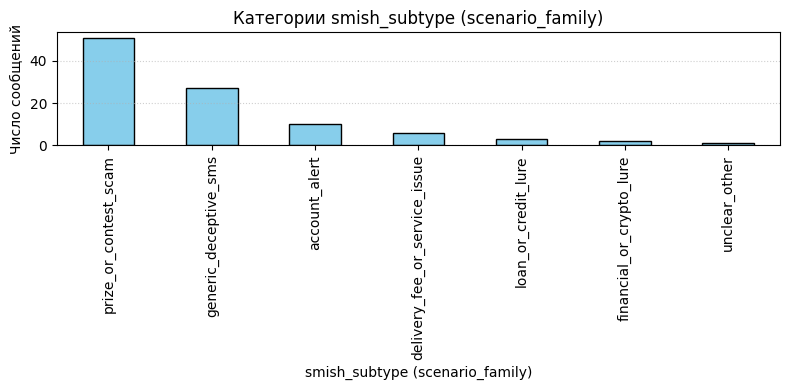


Wrote /Users/askar/projects/antifraud-deepfake-detection/v2/outputs/tables/mendeley_smishing_annotation_summary.csv


In [9]:
# ── 5. Post-annotation stats ─────────────────────────────────────────────────
import matplotlib.pyplot as plt

rows = ac.load_jsonl(OUT_JSONL)
if not rows:
    print("No annotations yet — run the annotation cell first.")
else:
    pdf = pd.DataFrame(rows)
    print("N annotated:", len(pdf))
    print("\n--- smish_subtype (scenario_family) ---")
    subtype_counts = pdf["scenario_family"].value_counts()
    print(subtype_counts)
    yes_share = (pdf["core_candidate"] == "yes").mean()
    print(f"\ncore_candidate=yes share: {yes_share:.1%}")
    for col in [
        "has_link_or_url",
        "has_phone_or_reply_cta",
        "has_payment_request",
        "has_credential_or_verification_request",
        "has_urgency",
        "has_brand_impersonation",
    ]:
        if col in pdf.columns:
            fr = (pdf[col] == "yes").mean()
            print(f"{col} == yes: {fr:.1%}")
    # Barplot по категориям
    plt.figure(figsize=(8, 4))
    subtype_counts.plot(kind="bar", color="skyblue", edgecolor="black")
    plt.title("Категории smish_subtype (scenario_family)")
    plt.xlabel("smish_subtype (scenario_family)")
    plt.ylabel("Число сообщений")
    plt.grid(axis="y", linestyle=":", alpha=0.6)
    plt.tight_layout()
    plt.show()

    summ_path = OUT_TABLES / "mendeley_smishing_annotation_summary.csv"
    pdf.groupby("scenario_family").size().to_csv(summ_path)
    print("\nWrote", summ_path)